# Chagas Detection using single-lead logistic regression approach

### Import libraries

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix,  ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import learning_curve
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
SEED = 54321

### Loading the data

In [4]:
# Load CSVs into DataFrame
samitrop_df = pd.read_csv('data/samitrop_4_vars_corrected.csv')
code15_df = pd.read_csv('data/code15_part0_4_vars.csv')

In [5]:
# Clearing the unnecessary index column 
samitrop_df = samitrop_df.drop(['Unnamed: 0','Dataset'], axis=1)
code15_df = code15_df.drop(['Unnamed: 0','Dataset'], axis=1)

In [6]:
# Original size of the code15 dataset
code15_df.shape

(20001, 5)

In [7]:
# Finding NULL values from the dataset, these values presented an error earlier when compiling the info for the data
code15_df[code15_df['Average heart rate'] == '~'].shape

(62, 5)

In [8]:
# Removing the NULL values from the data
code15_df_clean = code15_df.loc[code15_df['Average heart rate'] != '~']
code15_df_clean.shape

(19939, 5)

In [9]:
# Separating the SaMi-Trop dataset into train and test splits
st_data = samitrop_df.drop(['Chagas label'], axis=1)
st_label = samitrop_df['Chagas label']
st_X_train, st_X_test, st_y_train, st_y_test = train_test_split(st_data, st_label, test_size=0.25, random_state=SEED)

In [10]:
# Separating the CODE-15% dataset into train and test splits
c15_data = code15_df_clean.drop(['Chagas label'], axis=1)
c15_label = code15_df_clean['Chagas label']
c15_X_train, c15_X_test, c15_y_train, c15_y_test = train_test_split(c15_data, c15_label, test_size=0.25, random_state=SEED)

In [11]:
c15_X_train.shape

(14954, 4)

In [12]:
# Merging the datasets into the final train and test splits
X_train = pd.concat([c15_X_train, st_X_train], axis=0)
X_test = pd.concat([c15_X_test, st_X_test], axis=0)
y_train = pd.concat([c15_y_train, st_y_train], axis=0)
y_test = pd.concat([c15_y_test, st_y_test], axis=0)

In [13]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [14]:
# Converting the Chagas labels into a 0 or 1 (binary) list for ease of processing
y_train_binary = []
for y in y_train:
    if y == False:
        y_train_binary.append(0)
    else:
        y_train_binary.append(1)

In [15]:
# Printing out counts that will be used in the class_weights variable below
print(f"False labels: {y_train_binary.count(0)}")
false_labels = y_train_binary.count(0)
print(f"True labels: {y_train_binary.count(1)}")
true_labels = y_train_binary.count(1)
print(f"Total = {len(y_train_binary)}")
total_labels = len(y_train_binary)

False labels: 15237
True labels: 939
Total = 16176


## Refining the model using balanced_accuracy and ROC curve

In [16]:
# Preparing class weights to help balance the model
class_weights = {0: total_labels/(2*false_labels), 1: total_labels/(2*true_labels)}

In [17]:
# Hyperparameters to tune the logistic regression modeld
param_grid = {'penalty': ['l2', None], 'C':[0.0001,0.001,0.01,0.1,1,10], 'solver':['lbfgs']}

In [57]:
Parameter for how to balance the grid search scoring system
score='balanced_accuracy'

# Declaring our initial model object
model_lr = LogisticRegression(class_weight=class_weights, random_state=SEED)

print(f'Tuning logistic regression ...........................')
# create a GridSearchCV object for this model
grid_search = GridSearchCV(model_lr, param_grid, cv=5, scoring=score, refit=True, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best validation score: {grid_search.best_score_}')

model_lr.fit(X_train_scaled, y_train_binary)

NameError: name 'class_weights' is not defined

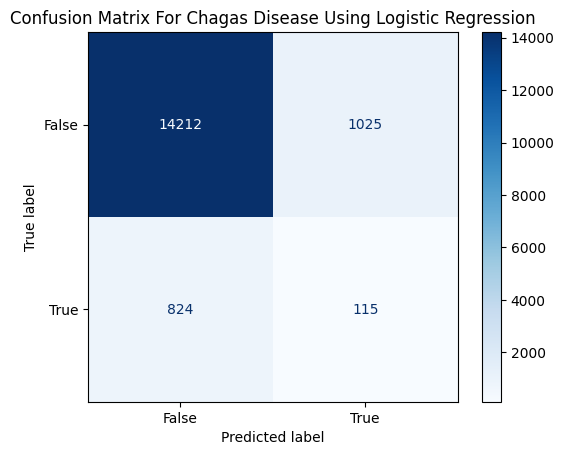

In [58]:
# first we need the model predictions 
predictions = grid_search.predict(X_train_scaled)

# next we can use the confusion_matrix function to get the confusion matrix
cm = confusion_matrix(y_train, predictions)

# we can use the ConfusionMatrixDisplay to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix For Chagas Disease Using Logistic Regression')
plt.show()

In [59]:
print(classification_report(y_train, predictions, target_names=['False', 'True']))

              precision    recall  f1-score   support

       False       0.95      0.93      0.94     15237
        True       0.10      0.12      0.11       939

    accuracy                           0.89     16176
   macro avg       0.52      0.53      0.52     16176
weighted avg       0.90      0.89      0.89     16176



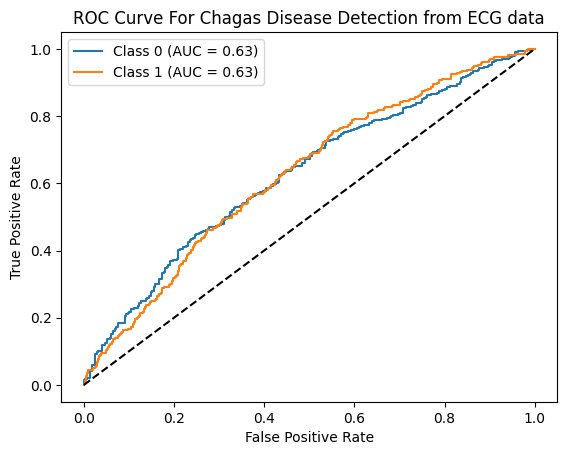

In [60]:
probs = grid_search.predict_proba(X_test_scaled)
fpr = dict()
tpr = dict()
roc_auc = {0:0, 1:0}
for i in range(2):
    fpr[i], tpr[i], _ = roc_curve(y_test, probs[:, i], pos_label=i)
    y_test_i = np.array(y_test == i).astype(int)
    roc_auc[i] = roc_auc_score(y_test_i, probs[:, i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve For Chagas Disease Detection from ECG data')
plt.legend()
plt.show()

## Refining the model using Precision-Recall AUC & SMOTE

In [16]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

In [18]:
# Hyperparameters to tune the logistic regression modeld
param_grid = {'o__sampling_strategy': [0,1,0.25,0.5,0.75,1],'model__penalty': ['l1','l2', None], 'model__C':[0.0001,0.001,0.01,0.1,1,10], 'model__solver':['saga']}

In [19]:
# Parameter for how to balance the grid search scoring system
over = BorderlineSMOTE()
model_pip = Pipeline([('o',over),('model', LogisticRegression(random_state=SEED))])
score = 'f1'

print(f'Tuning logistic regression ...........................')
# create a GridSearchCV object for this model
grid_search = GridSearchCV(model_pip, param_grid, cv=5, scoring=score, refit=True, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best validation score: {grid_search.best_score_}')

Tuning logistic regression ...........................
Best parameters: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'saga', 'o__sampling_strategy': 1}
Best validation score: 0.13697650922238255


In [1]:
# first we need the model predictions 
predictions = grid_search.predict(X_train_scaled)

# next we can use the confusion_matrix function to get the confusion matrix
cm = confusion_matrix(y_train, predictions)

# we can use the ConfusionMatrixDisplay to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix For Chagas Disease Using Logistic Regression')
plt.show()

NameError: name 'grid_search' is not defined

In [27]:
print(classification_report(y_train, predictions, target_names=['False', 'True']))

              precision    recall  f1-score   support

       False       0.94      1.00      0.97     15237
        True       0.00      0.00      0.00       939

    accuracy                           0.94     16176
   macro avg       0.47      0.50      0.49     16176
weighted avg       0.89      0.94      0.91     16176



In [ ]:
from sklearn.metrics import precision_recall_curve, auc
s
# Calculate precision and recall values
precision, recall, thresholds = precision_recall_curve(y_train, predictions, pos_label=True)

# Calculate AUC score
auc_score = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.fill_between(recall, precision, alpha=0.2, label=f'AUC = {auc_score:.2f}')
plt.legend(loc='lower left')
plt.show()

print(f"AUC: {auc_score}")